In [1]:
!python -m spacy download 'pt_core_news_md'
!git clone https://github.com/roneysco/Fake.br-Corpus.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 18.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Cloning into 'Fake.br-Corpus'...
remote: Enumerating objects: 28763, done.
remote: Total 28763 (delta 0), reused 0 (delta 0), pack-reused 28763 (from 1)
Receiving objects: 100% (28763/28763), 37.10 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (14129/14129), done.
Updating files: 100% (21602/21602), done.


In [2]:
#Importação das bibliotecas, carregando modelo médio e mostrando pipeline

import random
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import spacy
from spacy import displacy

nlp = spacy.load("pt_core_news_md")
nlp.pipe_names

['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']

In [3]:
#Carregando os textos (Noticias falsas e verdadeiras)

pasta_true = Path("Fake.br-Corpus/full_texts/true")
pasta_fake = Path("Fake.br-Corpus/full_texts/fake")

#Passando para uma lista
textos_true = []
for arq in sorted(pasta_true.glob("*.txt")):
    textos_true.append(arq.read_text(encoding="utf-8", errors="ignore").strip())

textos_fake = []
for arq in sorted(pasta_fake.glob("*.txt")):
    textos_fake.append(arq.read_text(encoding="utf-8", errors="ignore").strip())

#Tamanho de ambos e começo do texto das noticias verdadeiras
print(len(textos_true), len(textos_fake))
print(textos_true[0][:300])

3600 3600
﻿O Podemos decidiu  expulsar o deputado federal Carlos Gaguim do partido após a Polícia Federal fazer buscas a apreensões no gabinete dele na Câmara. Com isso, a legenda abre espaço para receber a senadora expulsa pelo PMDB, Katia Abreu. Por meio de nota, a legenda informou que o afastamento do parl


In [4]:
#200 de cada, no final subo pra 3600
random.seed(42)
amostra_true = random.sample(textos_true, 200)
amostra_fake = random.sample(textos_fake, 200)

In [5]:
#Processamento dos textos
docs_true = list(nlp.pipe(amostra_true, batch_size=32))
docs_fake = list(nlp.pipe(amostra_fake, batch_size=32))

print(len(docs_true), len(docs_fake))

200 200


In [6]:
#Contador de frequencia das palavras de cada um dos textos

freq_true = Counter()
for doc in docs_true:
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space or not token.is_alpha:
            continue
        freq_true[token.lemma_.lower()] += 1

freq_fake = Counter()
for doc in docs_fake:
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space or not token.is_alpha:
            continue
        freq_fake[token.lemma_.lower()] += 1

print(freq_true.most_common(20))
print()
print(freq_fake.most_common(20))

[('ser', 862), ('ano', 846), ('haver', 626), ('dizer', 583), ('lula', 579), ('ter', 571), ('presidente', 518), ('federal', 476), ('afirmar', 473), ('público', 460), ('governo', 431), ('país', 401), ('caso', 396), ('dia', 393), ('pessoa', 371), ('brasil', 330), ('ministro', 323), ('temer', 305), ('fazer', 289), ('político', 288)]

[('lula', 196), ('dizer', 151), ('ser', 149), ('ter', 103), ('ano', 100), ('brasil', 98), ('presidente', 93), ('dilma', 88), ('haver', 84), ('país', 79), ('federal', 77), ('pessoa', 65), ('pt', 64), ('ministro', 62), ('moro', 61), ('governo', 59), ('rede', 58), ('deputado', 58), ('acordo', 57), ('temer', 57)]


In [7]:
# mesma coisa sem lematizar, pra ver o que muda no ranking
freq_cru = Counter()
for doc in docs_true:
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space or not token.is_alpha:
            continue
        freq_cru[token.text.lower()] += 1

print(freq_cru.most_common(15))
print(freq_true.most_common(15))

[('lula', 579), ('anos', 559), ('presidente', 503), ('disse', 496), ('federal', 449), ('governo', 395), ('há', 365), ('brasil', 330), ('país', 306), ('pessoas', 298), ('caso', 291), ('temer', 289), ('ano', 287), ('público', 287), ('dia', 281)]
[('ser', 862), ('ano', 846), ('haver', 626), ('dizer', 583), ('lula', 579), ('ter', 571), ('presidente', 518), ('federal', 476), ('afirmar', 473), ('público', 460), ('governo', 431), ('país', 401), ('caso', 396), ('dia', 393), ('pessoa', 371)]


In [8]:
#Proporção dos POS de ambos textos
pos_true = Counter()
for doc in docs_true:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_true[token.pos_] += 1

pos_fake = Counter()
for doc in docs_fake:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_fake[token.pos_] += 1

total_true = sum(pos_true.values())
total_fake = sum(pos_fake.values())

# proporção e não contagem, os dois grupos têm tamanhos diferentes
for tag, n in pos_true.most_common(12):
    print(tag, round(n / total_true, 4), round(pos_fake[tag] / total_fake, 4))

NOUN 0.232 0.2181
ADP 0.1818 0.1664
VERB 0.1239 0.1318
DET 0.1043 0.1066
PROPN 0.1025 0.1255
ADJ 0.0507 0.0491
ADV 0.0425 0.0437
PRON 0.0412 0.0369
SCONJ 0.0338 0.0338
AUX 0.0322 0.0361
CCONJ 0.0306 0.0265
NUM 0.0226 0.0227


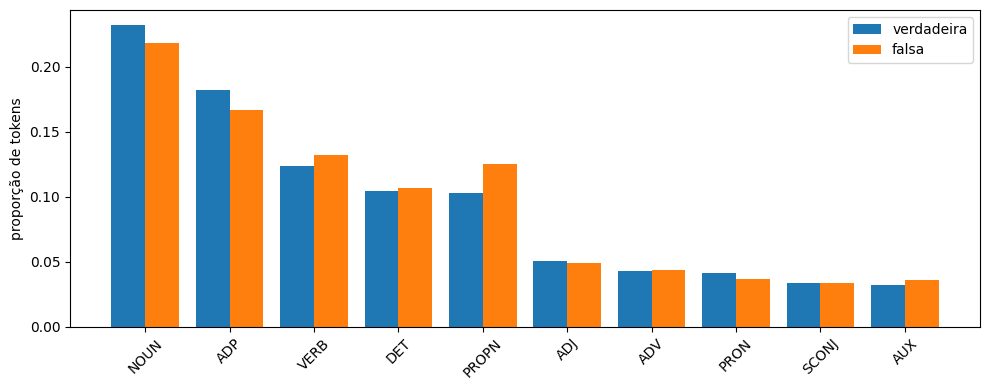

In [9]:
#em forma de gráfico os 10 mais comuns

tags = [t for t, _ in pos_true.most_common(10)]
p_true = [pos_true[t] / total_true for t in tags]
p_fake = [pos_fake[t] / total_fake for t in tags]

x = range(len(tags))
plt.figure(figsize=(10, 4))
plt.bar([i - 0.2 for i in x], p_true, width=0.4, label="verdadeira")
plt.bar([i + 0.2 for i in x], p_fake, width=0.4, label="falsa")
plt.xticks(list(x), tags, rotation=45)
plt.ylabel("proporção de tokens")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#conferir os rótulos que o modelo usa antes de filtrar por eles
print(Counter(ent.label_ for doc in docs_true for ent in doc.ents))
print(Counter(ent.label_ for doc in docs_fake for ent in doc.ents))

Counter({'PER': 6149, 'LOC': 5652, 'ORG': 2916, 'MISC': 1678})
Counter({'PER': 1494, 'LOC': 852, 'ORG': 552, 'MISC': 401})


In [11]:
#Filtro das palavras pertecentes as 3 mais comuns entidades
for rotulo in ["PER", "ORG", "LOC"]:
    ents_true = Counter()
    for doc in docs_true:
        for ent in doc.ents:
            if ent.label_ == rotulo:
                ents_true[ent.text.strip()] += 1

    ents_fake = Counter()
    for doc in docs_fake:
        for ent in doc.ents:
            if ent.label_ == rotulo:
                ents_fake[ent.text.strip()] += 1

    print(rotulo)
    print("true:", ents_true.most_common(10))
    print("fake:", ents_fake.most_common(10))
    print()

PER
true: [('Lula', 428), ('Temer', 179), ('Lava Jato', 152), ('Trump', 111), ('Michel Temer', 96), ('Joesley', 81), ('Luiz Inácio Lula da Silva', 69), ('Moro', 67), ('Aécio', 61), ('Dilma', 52)]
fake: [('Lula', 149), ('Dilma', 62), ('Michel Temer', 28), ('Cunha', 26), ('Sérgio Moro', 25), ('Temer', 24), ('Moro', 21), ('Lava-Jato', 17), ('Lava Jato', 17), ('Aécio', 17)]

ORG
true: [('PT', 127), ('JBS', 99), ('Odebrecht', 92), ('PMDB', 71), ('PSDB', 67), ('Justiça', 64), ('MPF', 57), ('Operação Lava Jato', 49), ('Petrobrás', 45), ('Constituição', 41)]
fake: [('PT', 63), ('Odebrecht', 26), ('Petrobras', 23), ('Globo', 12), ('Operação Lava Jato', 12), ('Exército', 12), ('PSDB', 11), ('PGR', 11), ('MPF', 10), ('PMDB', 8)]

LOC
true: [('Brasil', 268), ('STF', 199), ('Estado', 117), ('EUA', 113), ('Coreia do Norte', 99), ('São Paulo', 85), ('Supremo Tribunal Federal', 82), ('Ministério Público', 75), ('Estados Unidos', 73), ('Supremo', 70)]
fake: [('Brasil', 72), ('EUA', 28), ('STF', 23), ('

In [12]:
#displacy mostrando as entidades
displacy.render(docs_fake[0][:80].as_doc(), style="ent", jupyter=True)

In [13]:
#mesma coisa só que do texto verdadeiro
displacy.render(docs_true[0][:80].as_doc(), style="ent", jupyter=True)

In [14]:
#displacy da frase mostrando a dependencia
sent = list(docs_true[0].sents)[0]
displacy.render(sent.as_doc(), style="dep", jupyter=True,
                options={"compact": True, "distance": 90})